In [15]:
from zafpy import *
import numpy as np
from numpy.linalg import det
import matplotlib.pyplot as plt
import cmath

In [ ]:
# Define drift kinetic dispersion relation from Ronald's paper

massratio = 10 #3671
vthe = 0.05 # 1  # Thermal velocity electrons
omegace = -1 # electron cyclotron frequency
betae = 2*vthe**2  #2
#assume Ti=Te
vthi = vthe / np.sqrt(massratio)
vAe = vthe / np.sqrt(betae/2) # ion Alfven velocity
vAi = vAe / np.sqrt(massratio) # ion Alfven velocity
omegaci = - omegace / massratio
betai = betae


kpar = .4 # parallel wave number
kperp = 0 # perpendicular wave number
c = 1 # speed of light

omegape = c * (-omegace) / vAe
omegapi = c * (omegaci) / vAi
omegap= np.sqrt(omegape**2 + omegapi**2)
vA = np.sqrt(vAe**2*vAi**2/(vAe**2 + vAi**2)) # Alfven velocity
beta = betae + betai

print(f"vAe={vAe},  vAi={vAi}, vA={vA}")
print ("omegape= ", omegape)
print("vthe= ", vthe)
print("rhohat= ", -vthe/omegace)

ions = False
Bpar = False


# Dispersion relation in symbolic variables (here k = kx)
# Note that Dxx gives the Langmuir waves and Dxy = 0 if there is no longitudinal drift (then the zeros of D are the combined zeros of Dxx, Dyy and Dzz)
def D(omega,kperp):
    zetai = omega / (np.sqrt(2) * kpar * vthi)
    zetae = omega / (np.sqrt(2) * kpar * vthe)
    Dxx = - kpar**2 + (omega/vAe)**2 + (omega/c)**2 
    Dxy = 1j * omega * omegace /(vAe)**2
    Dxz = kpar * kperp
    Dyy =  - kpar**2 - kperp**2  + (omega/vAe)**2  + (omega/c)**2 - betae*(kperp**2) 
    Dyz = 0
    Dzz = - kperp**2 + (omega/kpar)**2 * omegape**2/(vthe**2 * c**2) * ( 1.0 + zetae * Z(zetae)) + (omega/c)**2 
    
    # Dxx = (omega/c)**2 - kpar**2 + beta/(2*vthe)**2 * omega**2
    # Dxy = 1j * omega * omegace * beta/(2*vthe)**2
    # Dxz = kpar * kperp
    # Dyy = (omega/c)**2 - kpar**2 - kperp**2  + beta/(2*vthe)**2 * omega**2  + beta * (kperp**2) * (zetae * Z(zetae)) 
    # Dyz = 1j*kperp*omega* omegace/kpar * beta/(2*vthe)**2 * ( 1.0 + zetae * Z(zetae))
    # Dzz = (omega/c)**2 - kperp**2 + (omega/kpar)**2 * beta * omegace**2/(4*vthe**4) * ( 1.0 + zetae * Z(zetae))
    if ions: 
        Dxx = Dxx + omega**2/vAi**2
        Dxy = Dxy + 1j * omega * omegaci / vAi**2
        Dyy = Dyy + omega**2/vAi**2 - betai*(kperp**2)
        Dyz = Dyz + 0
        Dzz = Dzz + (omega/kpar)**2 * omegapi**2/(vthi**2 * c**2) * ( 1.0 + zetai * Z(zetai))
        
    if Bpar:
        Dyy = Dyy + beta * (kperp**2) * (zetae * Z(zetae)) 
        Dyz = Dyz + 1j*kperp*omega* omegace/kpar * beta/(2*vthe)**2 * ( 1.0 + zetae * Z(zetae))
    # 
    
    Dyx = - Dxy
    Dzx = Dxz
    Dzy = -Dyz
    
    # print(Dxx)
    # print(Dxy)
    # print(Dyx)
    # print(Dyy)
    # print(Dzz)
    return Dxz*(Dyx*Dzy - Dzx*Dyy) - Dyz*(Dxx*Dzy-Dzx*Dxy)  + Dzz*(Dxx * Dyy - Dxy*Dyx)   # development on the last column
    #return Dxx * Dyy - Dxy*Dyx 
    #return Dzz

print("D=",D(1,0))


vAe=1.0,  vAi=0.31622776601683794, vA=0.30151134457776363
omegape=  1.0
vthe=  1
rhohat=  1.0
D= 17.2956 + 1.15806356577738*sqrt(pi)*(-9.11399234552428 + I)


- In order to find the roots of the dispersion function for given k, which is a complex function we plot it with mpmath.cplot
- the complex argument (phase) is shown as color (hue) and the magnitude is show as brightness.
- This means that zeros change quickly around a zero and the white region correspond to very large value, where contours integrals are hard to approximate numerically and so should be avoided

Dispersion function for k =  0


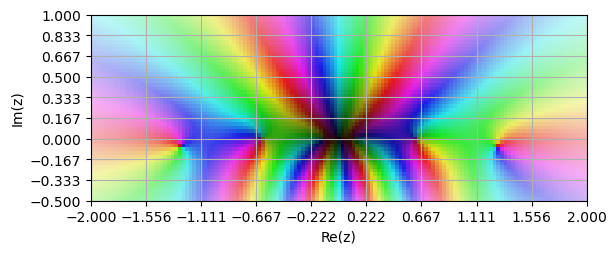

In [17]:
zaf=zafpy(D,kperp)
xmin= -2
xmax= 2
ymin = -.5
ymax = 1
#mp.cplot(zaf.D, re=[xmin,xmax], im=[ymin,ymax], points=10000)
fig = plt.figure()
ax = plt.subplot(111)
mp.cplot(zaf.D, re=[xmin,xmax], im=[ymin,ymax], points=7000, axes=ax)
ax.grid()
ax.set_xticks(np.linspace(xmin,xmax,10))
ax.set_yticks(np.linspace(ymin,ymax,10))
print("Dispersion function for k = ", kperp )

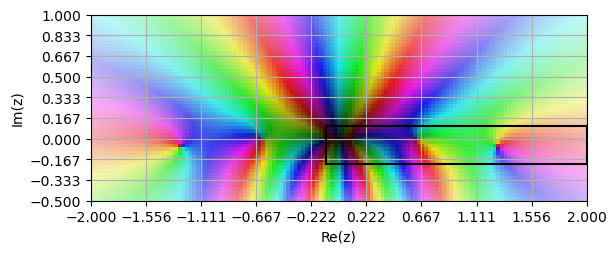

In [18]:
# Choose box where zeros are searched for (need to be positively oriented)
z0 = -.1 - .2j
z1 = 2. - .2j
z2 = 2. + 0.1j
z3 = -.1 + 0.1j

ax.plot([z0.real,z1.real],[z0.imag,z1.imag], 'k')
ax.plot([z1.real,z2.real],[z1.imag,z2.imag], 'k')
ax.plot([z2.real,z3.real],[z2.imag,z3.imag], 'k')
ax.plot([z3.real,z0.real],[z3.imag,z0.imag], 'k')
display(fig)

### Numerical evaluation of the zeros using contour integrals
- we define quadrilateral boxes by 4 complex numbers (z0,z1,z2,z3) ordered anti-clockwise on which contours integrals are computed
- We need to use small boxes around the zeros to avoid going to high brightness zones where contour integrals will be hard to evaluate numerically

In [19]:
nzeros = zaf.count_zeros(z0, z1, z2, z3)
print('number of zeros in box', nzeros)
if nzeros > 0.5: 
    zaf.zeros=[]
    zeros=zaf.get_zeros(z0, z1, z2, z3)

    print("Zeros of D in box")
    for z in zeros:
        print(z)
        if mp.fabs(zaf.D(z)) > 1e-12:
            print("Value of D at zero ",zaf.D(z))       
    zero_max=zeros[np.argmax(np.imag(zeros))]
    print('------------------------')
    print('kperp=',kperp)
    print('k=',np.sqrt(kpar**2+kperp**2))
    print('zero with largest imaginary part (omega_j):', zero_max)

number of zeros in box 4.999999999999999
Zeros of D in box
(1.2850569696537468-0.06612795869074946j)
(-2.3793629081196693e-08-1.946335632423256e-06j)
(1.311967865273201e-08+1.938775252703011e-06j)
(0.12749172176353749+4.037420619245194e-19j)
(0.6274917217634903-1.797254680103209e-14j)
------------------------
kperp= 0
k= 0.4
zero with largest imaginary part (omega_j): (1.311967865273201e-08+1.938775252703011e-06j)


In [20]:
a = 1/c**2 + 1/vAe**2
delta = (1+4*a*kpar**2)
om1 = (1 + np.sqrt(delta))/(2*a)
om2 = (1 - np.sqrt(delta))/(2*a)
print(delta, om1,om2)

2.2800000000000002 0.6274917217635375 -0.1274917217635375


In [21]:
kpar = 0.4
beta = .1
kD = np.array([.01, .1, .2, .3, 0.4, .5, .7])
#om1 = np.array([0.5098076211353315, 0.5372281323269015, 0.5778719262151013, 0.6274917217635375, 0.683012701892219, 0.8045268253204716, 0.9337397165588671, 0.9778029157808681, 1.4778029157808668])
#om2 = np.array([1.0151975255436134, 0.037228132326048886, 0.07787192621523423, 0.1274917217635374, 0.18301270189224703, 0.3045268253204707, 0.4337397165588671])
om1D = np.array([0.8602118869201283, 0.8657108753110399, 0.8735543675653487, 0.8696792029208885,0.851547584775488, 0.825254924900535, 0.7689532883309284])
om2D = np.array([1.8600843336141324, 1.8570042610179351, 1.875092161324746, 1.9520865728524641, 2.092617475863168, 2.2813276987926585, 2.7458316726202048])

beta = .01
om1Dl = np.array([0.3932204294009907, 0.40544932619030893, 0.44065205707584987, 0.4943585899448341, 0.561489587403569, 0.6364518340251925, 0.8018328569391412])
om2Dl = np.array([0.4031184478814031, 0.41504978006320814, 0.4492942815129649, 0.5012126045004586,0.5662475531762234, 0.6419501621900845, 0.8111760170733557])

In [22]:
k = np.array([.01, .1, .2, .3, 0.4, .5, .7, 1])
om1 = np.array([0.33874616283685105, 0.3501471361317989, 0.38343861650399663, 0.4370494885765018, 0.5160568991288831, 0.6171022734415266, 0.7717128706943643, 1.0289651979659298])
om2 = np.array([0.4296366216736169, 0.43922342057826, 0.46702387035887294, 0.509185816805189,0.5582688749756815, 0.6324630207200808, 0.874591887502455, 1.1399772647826398])

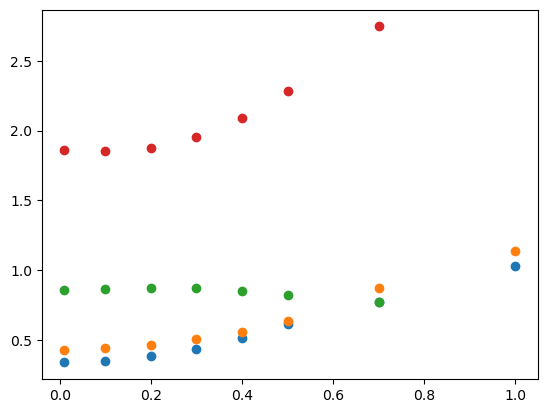

In [23]:
plt.plot(k,om1, 'o')
plt.plot(k,om2, 'o')
plt.plot(kD,om1D, 'o')
plt.plot(kD,om2D, 'o')
# plt.plot(k,om1Dl, 'o')
# plt.plot(k,om2Dl, 'o')

aa=12.0 bb=0.0
y2-y3=bb/aa=0.0
kpar=0.4  omega=-0.11547005383792518 
  | Dxx=2.7755575615628914e-17  Dxy=0j|
  | Dyx=(-0-0j)  Dyy=2.7755575615628914e-17|
-----------------------------
kpar=0.4  omega=0.11547005383792518 
  | Dxx=2.7755575615628914e-17  Dxy=0j|
  | Dyx=(-0-0j)  Dyy=2.7755575615628914e-17|
-----------------------------
kpar=0.4  omega=0.11547005383792518 
  | Dxx=2.7755575615628914e-17  Dxy=0j|
  | Dyx=(-0-0j)  Dyy=2.7755575615628914e-17|
-----------------------------
kpar=0.4  omega=-0.11547005383792518 
  | Dxx=2.7755575615628914e-17  Dxy=0j|
  | Dyx=(-0-0j)  Dyy=2.7755575615628914e-17|
-----------------------------


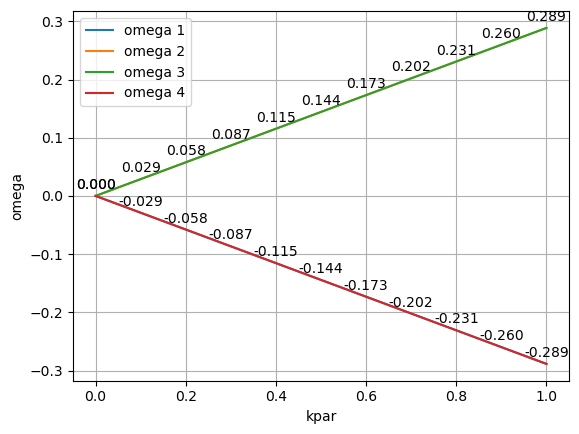

In [24]:
# Assume kperp = 0, calculate omega(k) for diet[Dxx,Dxy,Dyx,Dyy]=0
import matplotlib.pyplot as plt
import numpy as np


massratio = 10 #3671
vthe = 0.05 # 1  # Thermal velocity electrons
omegace = -1 # electron cyclotron frequency
betae = 2*vthe**2  #2
#assume Ti=Te
vthi = vthe / np.sqrt(massratio)
vAe = vthe / np.sqrt(betae/2) # ion Alfven velocity
vAi = vAe / np.sqrt(massratio) # ion Alfven velocity
omegaci = - omegace / massratio
betai = betae


kpar = .4 # parallel wave number
kperp = 0 # perpendicular wave number
c = 1 # speed of light

omegape = c * (-omegace) / vAe
omegapi = c * (omegaci) / vAi
omegap= np.sqrt(omegape**2 + omegapi**2)
vA = np.sqrt(vAe**2*vAi**2/(vAe**2 + vAi**2)) # Alfven velocity
beta = betae + betai

ions = True

def print_D(kpar,omega):  
    Dxx = - kpar**2 + (omega/vAe)**2 + (omega/c)**2 
    Dxy = 1j * omega * omegace /(vAe)**2
    Dyy =  - kpar**2 - kperp**2  + (omega/vAe)**2  + (omega/c)**2 - betae*(kperp**2) 
    if ions:
        Dxx = Dxx + omega**2/vAi**2
        Dxy = Dxy + 1j * omega * omegaci / vAi**2
        Dyy = Dyy + omega**2/vAi**2 - betai*(kperp**2)
        
    Dyx = - Dxy
    
    print(f'kpar={kpar}  omega={omega} ')
    print(f'  | Dxx={Dxx}  Dxy={Dxy}|')
    print(f'  | Dyx={Dyx}  Dyy={Dyy}|')
    print('-----------------------------')
    
    
    
kpar_ana = np.linspace(0, 1.0, 11)    # Parallel wavenumber in 1/m
# solve ax^2-bx-c=0
aa= 1+c**2/vAe**2
bb= omegape**2/omegace
cc= (kpar_ana*c)**2

if ions:
    aa= 1+c**2/vA**2
    bb= omegape**2/omegace + omegapi**2/omegaci
    cc= (kpar_ana*c)**2  
print(f"aa={aa} bb={bb}")    

# Calculate delta
delta = np.sqrt(bb**2 + 4 * (aa) * (cc))

y1 = (bb - delta) / (2 * aa)
y2 = (bb + delta) / (2 * aa)
y3 = (-bb + delta) / (2 * aa)
y4 = -y2

print(f"y2-y3=bb/aa={bb/aa}")

# Print the result
plt.plot(kpar_ana, y1, label="omega 1")
plt.plot(kpar_ana, y2, label="omega 2")
plt.plot(kpar_ana, y3, label="omega 3")
plt.plot(kpar_ana, y4, label="omega 4")
plt.legend()
plt.grid(True)
plt.xlabel("kpar")
plt.ylabel("omega")

# Add annotations at each data point
for i in range(len(kpar_ana)):
    plt.annotate(f'{y1[i]:.3f}', (kpar_ana[i], y1[i]), 
                 textcoords="offset points",  # Position of the annotation text
                 xytext=(0,5),  # Offset 5 units above the point
                 ha='center')  # Horizontally centered alignment
    plt.annotate(f'{y2[i]:.3f}', (kpar_ana[i], y2[i]), 
                 textcoords="offset points",  # Position of the annotation text
                 xytext=(0,5),  # Offset 5 units above the point
                 ha='center')  # Horizontally centered alignment

print_D(kpar_ana[4],y1[4])
print_D(kpar_ana[4],y2[4])
print_D(kpar_ana[4],y3[4])
print_D(kpar_ana[4],y4[4])


aa=12.0 bb=0.0  (beta+1)*c^2=1.01
(beta+1)* c**2/ (1+c**2/vA**2)= 0.08416666666666667
kperp=0.4  omega=0.11604596790352807 
  | Dxx=0.1616  Dxy=0j|
  | Dyx=(-0-0j)  Dyy=-6.071532165918825e-17|
-----------------------------
kperp=0.4  omega=-0.11604596790352807 
  | Dxx=0.1616  Dxy=0j|
  | Dyx=(-0-0j)  Dyy=-6.071532165918825e-17|
-----------------------------


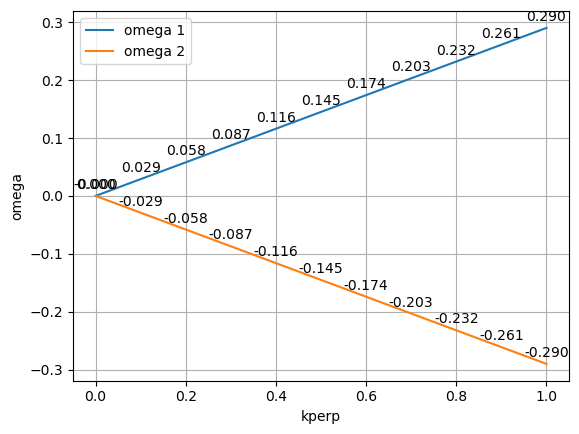

In [25]:
# Assume kparallel = 0, calculate omega(k) for diet[Dxx,Dxy,Dyx,Dyy]=0
import matplotlib.pyplot as plt
import numpy as np


massratio = 10 #3671
vthe = 0.05 # 1  # Thermal velocity electrons
omegace = -1 # electron cyclotron frequency
betae = 2*vthe**2  #2
#assume Ti=Te
vthi = vthe / np.sqrt(massratio)
vAe = vthe / np.sqrt(betae/2) # ion Alfven velocity
vAi = vAe / np.sqrt(massratio) # ion Alfven velocity
omegaci = - omegace / massratio
betai = betae


kpar = 0 # parallel wave number
kperp = 0.4 # perpendicular wave number
c = 1 # speed of light

omegape = c * (-omegace) / vAe
omegapi = c * (omegaci) / vAi
omegap= np.sqrt(omegape**2 + omegapi**2)
vA = np.sqrt(vAe**2*vAi**2/(vAe**2 + vAi**2)) # Alfven velocity
beta = betae + betai

ions = True

def print_D(kperp,omega):  
    Dxx = - kpar**2 + (omega/vAe)**2 + (omega/c)**2 
    Dxy = 1j * omega * omegace /(vAe)**2
    Dyy =  - kpar**2 - kperp**2  + (omega/vAe)**2  + (omega/c)**2 - betae*(kperp**2) 
    if ions:
        Dxx = Dxx + omega**2/vAi**2
        Dxy = Dxy + 1j * omega * omegaci / vAi**2
        Dyy = Dyy + omega**2/vAi**2 - betai*(kperp**2)
        
    Dyx = - Dxy
    
    print(f'kperp={kperp}  omega={omega} ')
    print(f'  | Dxx={Dxx}  Dxy={Dxy}|')
    print(f'  | Dyx={Dyx}  Dyy={Dyy}|')
    print('-----------------------------')
    
    
    
kperp_ana = np.linspace(0, 1.0, 11)    # 
# solve aa w^2 (aa w^2 - cc)=w^2 bb^2
# w^2 =0 or w^2 = cc/aa + bb^2/aa^2
aa= 1+c**2/vAe**2
bb= omegape**2/omegace
cc= (betae+1)*(kperp_ana*c)**2

if ions:
    aa= 1+c**2/vA**2
    bb= omegape**2/omegace + omegapi**2/omegaci
    cc= (beta+1)* (kperp_ana*c)**2
print(f"aa={aa} bb={bb}  (beta+1)*c^2={(beta+1)*c**2}")    


y1 = np.sqrt( (bb**2 + aa*cc)/aa**2)
y2 = -y1


print(f"(beta+1)* c**2/ (1+c**2/vA**2)= {(beta+1)*c**2/aa}")

# Print the result
plt.plot(kperp_ana, y1, label="omega 1")
plt.plot(kperp_ana, y2, label="omega 2")

plt.legend()
plt.grid(True)
plt.xlabel("kperp")
plt.ylabel("omega")

# Add annotations at each data point
for i in range(len(kperp_ana)):
    plt.annotate(f'{y1[i]:.3f}', (kperp_ana[i], y1[i]), 
                 textcoords="offset points",  # Position of the annotation text
                 xytext=(0,5),  # Offset 5 units above the point
                 ha='center')  # Horizontally centered alignment
    plt.annotate(f'{y2[i]:.3f}', (kperp_ana[i], y2[i]), 
                 textcoords="offset points",  # Position of the annotation text
                 xytext=(0,5),  # Offset 5 units above the point
                 ha='center')  # Horizontally centered alignment

print_D(kperp_ana[4],y1[4])
print_D(kperp_ana[4],y2[4])
